In [1]:
!nvidia-smi

Sun May  3 06:07:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [20]:
!pip install -q torch torchvision matplotlib transformers datasets

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from transformers import CLIPTokenizer, CLIPTextModel
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [22]:
dataset = load_dataset("cifar10")

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

def transform_fn(example):
    example["pixel_values"] = transform(example["img"])
    return example

dataset = dataset.with_transform(transform_fn)
train_dataset = dataset["train"]

from torch.utils.data import DataLoader
loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [23]:
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)

def encode_text(labels):
    texts = [classes[label] for label in labels]
    inputs = tokenizer(texts, padding=True, return_tensors="pt").to(device)
    outputs = text_encoder(**inputs)
    return outputs.last_hidden_state.mean(dim=1)

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.embeddings.position_embedding.weight              | UNEXPECTED |  | 
vision_model.post_layernorm.weight   

In [25]:
class SelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.query = nn.Conv2d(channels, channels//8, 1)
        self.key = nn.Conv2d(channels, channels//8, 1)
        self.value = nn.Conv2d(channels, channels, 1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        B,C,H,W = x.shape
        q = self.query(x).view(B, -1, H*W).permute(0,2,1)
        k = self.key(x).view(B, -1, H*W)
        attn = self.softmax(q * k)
        v = self.value(x).view(B, -1, H*W)

        out = v * attn.permute(0,2,1)
        out = out.view(B,C,H,W)

        return self.gamma*out + x

In [37]:
class CrossAttention(nn.Module):
    def __init__(self, img_dim, text_dim):
        super().__init__()
        self.q = nn.Linear(img_dim, img_dim)
        self.k = nn.Linear(text_dim, img_dim)
        self.v = nn.Linear(text_dim, img_dim)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, img_feat, text_feat):
        Q = self.q(img_feat)
        K = self.k(text_feat)
        V = self.v(text_feat)

        attn = self.softmax(Q @ K.T)
        return attn @ V + img_feat

In [38]:
class Generator(nn.Module):
    def __init__(self, z_dim, text_dim):
        super().__init__()

        self.fc = nn.Linear(z_dim, 256)

        self.cross_attn = CrossAttention(256, text_dim)

        self.net = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 3*64*64),
            nn.Tanh()
        )

    def forward(self, z, text_feat):
        x = self.fc(z)
        x = self.cross_attn(x, text_feat)
        out = self.net(x)
        return out.view(-1,3,64,64)

In [39]:
class Discriminator(nn.Module):
    def __init__(self, text_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3*64*64 + text_dim, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, text_feat):
        img = img.view(img.size(0), -1)
        x = torch.cat([img, text_feat], dim=1)
        return self.net(x).view(-1)

In [40]:
z_dim = 100
text_dim = 512
gen = Generator(z_dim, text_dim).to(device)
disc = Discriminator(text_dim).to(device)
criterion = nn.BCELoss()
opt_gen = optim.Adam(gen.parameters(), lr=2e-4)
opt_disc = optim.Adam(disc.parameters(), lr=2e-4)

In [49]:
epochs = 5
for epoch in range(epochs):
    for batch in loader:

        real = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        text_feat = encode_text(labels)

        noise = torch.randn(real.size(0), z_dim).to(device)
        fake = gen(noise, text_feat)

        real_loss = criterion(disc(real, text_feat), torch.ones(real.size(0)).to(device))
        fake_loss = criterion(disc(fake.detach(), text_feat), torch.zeros(real.size(0)).to(device))
        loss_disc = (real_loss + fake_loss)/2

        opt_disc.zero_grad()
        loss_disc.backward(retain_graph=True)
        opt_disc.step()


        loss_gen = criterion(disc(fake, text_feat), torch.ones(real.size(0)).to(device))

        opt_gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

    print(f"Epoch {epoch+1} | D Loss: {loss_disc:.4f} | G Loss: {loss_gen:.4f}")

Epoch 1 | D Loss: 0.0002 | G Loss: 11.1456
Epoch 2 | D Loss: 0.0000 | G Loss: 14.0636
Epoch 3 | D Loss: 0.0000 | G Loss: 14.6909
Epoch 4 | D Loss: 0.0000 | G Loss: 16.5022
Epoch 5 | D Loss: 0.0000 | G Loss: 100.0000


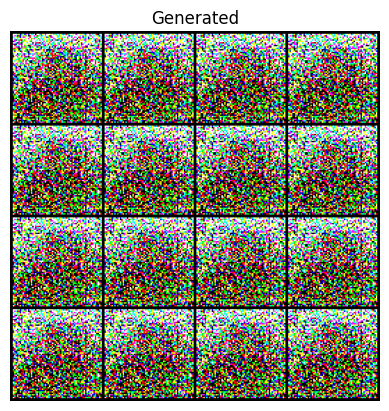

In [53]:
def show_images(images, title="Generated"):
    images = (images + 1) / 2
    grid = torchvision.utils.make_grid(images[:16], nrow=4)
    plt.imshow(grid.permute(1,2,0).cpu())
    plt.title(title)
    plt.axis("off")
    plt.show()

gen.eval()

label = torch.tensor([3]*16).to(device)  # cat
text_feat = encode_text(label)

noise = torch.randn(16, z_dim).to(device)

with torch.no_grad():
    fake_images = gen(noise, text_feat)

show_images(fake_images)

In [54]:
!pip install -q diffusers transformers accelerate torch

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

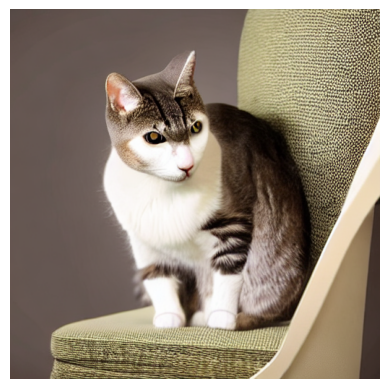

In [55]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

prompt = "a realistic cat sitting on a chair"

image = pipe(prompt).images[0]

plt.imshow(image)
plt.axis("off")